In [8]:
import json
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, multilabel_confusion_matrix

# ============ CONFIG ============
pred_csv = 'drug/drug_results_gpt41mini_v1_ext.csv'
gold_json = 'drug_ground_truth.json'
visit = 'Visit_2'  # must match the visit used for prediction
# ================================

# Cluster name -> number mapping
CLUSTER_NAME_TO_NUM = {
    'Sodium channel blockers': 1,
    'GABA-enhancing drugs': 2,
    'Calcium channel blocker (T-type)': 3,
    'SV2A modulator': 4,
    'Mixed-mechanism drugs': 5,
}
CLUSTER_NAMES = {v: k for k, v in CLUSTER_NAME_TO_NUM.items()}

# Load predictions
df_pred = pd.read_csv(pred_csv)
print(f'Predictions: {len(df_pred)} patients')
print(df_pred.head())

Predictions: 332 patients
           patient_id predicted_clusters
0    1_Nanyonga Aisha                  5
1    2_Mwania Sheldon                  1
2      3_Kazibwe Ryan               none
3  4_Asio Esther Jane                  5
4     5_Nalumu Martha                  5


In [9]:
# Load gold standard
with open(gold_json) as f:
    gold = json.load(f)

# Build gold cluster sets per patient for the target visit
gold_clusters = {}
for pid, visits in gold.items():
    v = visits.get(visit, {})
    if not v:
        continue
    nums = set()
    for cname in v.get('active_clusters', []):
        if cname in CLUSTER_NAME_TO_NUM:
            nums.add(CLUSTER_NAME_TO_NUM[cname])
    gold_clusters[pid] = nums

# Build pred cluster sets per patient
pred_clusters = {}
n_none_pred = 0  # count of valid "no medication" predictions
for _, row in df_pred.iterrows():
    pid = str(row['patient_id'])
    raw = str(row['predicted_clusters']).strip().lower()
    if raw == '' or raw == 'nan':
        pred_clusters[pid] = None  # parse failure
    elif raw == 'none' or raw == '0':
        pred_clusters[pid] = set()  # valid: no medication indicated
        n_none_pred += 1
    else:
        # Parse comma-separated cluster numbers, filtering to valid integers
        nums = set()
        for x in raw.split(','):
            x = x.strip()
            if x.isdigit():
                c = int(x)
                if 1 <= c <= 5:  # only valid cluster numbers
                    nums.add(c)
        pred_clusters[pid] = nums if nums else None  # empty after filtering = parse failure

# Align on common patients
common = sorted(set(gold_clusters.keys()) & set(pred_clusters.keys()))
n_parse_fail = sum(1 for pid in common if pred_clusters[pid] is None)
print(f'Gold patients: {len(gold_clusters)}')
print(f'Pred patients: {len(pred_clusters)}')
print(f'Common: {len(common)}')
print(f'Parse failures (in common): {n_parse_fail}')
print(f'No-medication predictions: {n_none_pred}')

Gold patients: 332
Pred patients: 332
Common: 332
Parse failures (in common): 0
No-medication predictions: 8


In [10]:
# print for each cluster, the number of patients that have it for gold and pred
# Valid clusters are 1-5 only
for c in range(1, 6):
    gold_count = sum(1 for pid in common if c in gold_clusters[pid])
    pred_count = sum(1 for pid in common if pred_clusters[pid] is not None and c in pred_clusters[pid])
    print(f'Cluster {c} ({CLUSTER_NAMES[c][:20]}): Gold {gold_count}, Pred {pred_count}')

# Also show empty set counts
gold_empty = sum(1 for pid in common if len(gold_clusters[pid]) == 0)
pred_empty = sum(1 for pid in common if pred_clusters[pid] is not None and len(pred_clusters[pid]) == 0)
print(f'\nNo medication (empty): Gold {gold_empty}, Pred {pred_empty}')

Cluster 1 (Sodium channel block): Gold 183, Pred 113
Cluster 2 (GABA-enhancing drugs): Gold 42, Pred 71
Cluster 3 (Calcium channel bloc): Gold 4, Pred 7
Cluster 4 (SV2A modulator): Gold 21, Pred 7
Cluster 5 (Mixed-mechanism drug): Gold 204, Pred 216

No medication (empty): Gold 1, Pred 8


In [11]:
# Filter to successfully parsed patients
valid = [pid for pid in common if pred_clusters[pid] is not None]
print(f'Valid (parsed) patients: {len(valid)}')

y_gold = [gold_clusters[pid] for pid in valid]
y_pred = [pred_clusters[pid] for pid in valid]

# === 1. Exact match (set equality) ===
exact_matches = sum(1 for g, p in zip(y_gold, y_pred) if g == p)
exact_acc = exact_matches / len(valid)
print(f'\n=== EXACT MATCH ===')
print(f'Exact match: {exact_matches}/{len(valid)} = {exact_acc:.3f}')

# === 2. Jaccard similarity (per patient, then average) ===
jaccards = []
for g, p in zip(y_gold, y_pred):
    if len(g | p) == 0:
        jaccards.append(1.0)  # both empty
    else:
        jaccards.append(len(g & p) / len(g | p))
mean_jaccard = np.mean(jaccards)
print(f'\n=== JACCARD SIMILARITY ===')
print(f'Mean Jaccard: {mean_jaccard:.3f}')

# === 3. Subset accuracy variants ===
# Gold is subset of pred (all true clusters captured)
gold_subset = sum(1 for g, p in zip(y_gold, y_pred) if g <= p) / len(valid)
# Pred is subset of gold (no false positives)
pred_subset = sum(1 for g, p in zip(y_gold, y_pred) if p <= g) / len(valid)
print(f'\n=== SUBSET RATES ===')
print(f'All true clusters captured (gold ⊆ pred): {gold_subset:.3f}')
print(f'No false positive clusters (pred ⊆ gold): {pred_subset:.3f}')

Valid (parsed) patients: 332

=== EXACT MATCH ===
Exact match: 111/332 = 0.334

=== JACCARD SIMILARITY ===
Mean Jaccard: 0.525

=== SUBSET RATES ===
All true clusters captured (gold ⊆ pred): 0.464
No false positive clusters (pred ⊆ gold): 0.578


In [12]:
# === 4. Per-cluster binary metrics ===
# Convert to multi-label binary arrays
all_clusters = [1, 2, 3, 4, 5]
y_gold_bin = np.array([[1 if c in g else 0 for c in all_clusters] for g in y_gold])
y_pred_bin = np.array([[1 if c in p else 0 for c in all_clusters] for p in y_pred])

cluster_labels = [f'C{c}: {CLUSTER_NAMES[c][:25]}' for c in all_clusters]
print('=== PER-CLUSTER CLASSIFICATION REPORT ===')
print(classification_report(y_gold_bin, y_pred_bin, target_names=cluster_labels, zero_division=0))

# Compute TP, FP, TN, FN for each cluster
print('\n=== PER-CLUSTER CONFUSION METRICS ===')
for i, c in enumerate(all_clusters):
    tp = np.sum((y_gold_bin[:, i] == 1) & (y_pred_bin[:, i] == 1))
    fp = np.sum((y_gold_bin[:, i] == 0) & (y_pred_bin[:, i] == 1))
    tn = np.sum((y_gold_bin[:, i] == 0) & (y_pred_bin[:, i] == 0))
    fn = np.sum((y_gold_bin[:, i] == 1) & (y_pred_bin[:, i] == 0))
    print(f'{cluster_labels[i]}: TP={tp}, FP={fp}, TN={tn}, FN={fn}')

=== PER-CLUSTER CLASSIFICATION REPORT ===
                               precision    recall  f1-score   support

  C1: Sodium channel blockers       0.80      0.49      0.61       183
     C2: GABA-enhancing drugs       0.18      0.31      0.23        42
C3: Calcium channel blocker (       0.29      0.50      0.36         4
           C4: SV2A modulator       0.00      0.00      0.00        21
    C5: Mixed-mechanism drugs       0.70      0.74      0.72       204

                    micro avg       0.62      0.56      0.59       454
                    macro avg       0.39      0.41      0.38       454
                 weighted avg       0.65      0.56      0.59       454
                  samples avg       0.64      0.59      0.59       454


=== PER-CLUSTER CONFUSION METRICS ===
C1: Sodium channel blockers: TP=90, FP=23, TN=126, FN=93
C2: GABA-enhancing drugs: TP=13, FP=58, TN=232, FN=29
C3: Calcium channel blocker (: TP=2, FP=5, TN=323, FN=2
C4: SV2A modulator: TP=0, FP=7, TN=304,

In [13]:
# === 5. Overall sample-level precision, recall, F1 ===
precisions, recalls, f1s = [], [], []
for g, p in zip(y_gold, y_pred):
    if len(p) == 0 and len(g) == 0:
        precisions.append(1.0); recalls.append(1.0); f1s.append(1.0)
    elif len(p) == 0:
        precisions.append(0.0); recalls.append(0.0); f1s.append(0.0)
    elif len(g) == 0:
        precisions.append(0.0); recalls.append(0.0); f1s.append(0.0)
    else:
        prec = len(g & p) / len(p)
        rec = len(g & p) / len(g)
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        precisions.append(prec); recalls.append(rec); f1s.append(f1)

print('=== SAMPLE-LEVEL AVERAGES ===')
print(f'Precision: {np.mean(precisions):.3f}')
print(f'Recall:    {np.mean(recalls):.3f}')
print(f'F1:        {np.mean(f1s):.3f}')

# === 6. Hamming loss ===
hamming = np.mean(y_gold_bin != y_pred_bin)
print(f'\nHamming loss: {hamming:.3f}')

=== SAMPLE-LEVEL AVERAGES ===
Precision: 0.646
Recall:    0.597
F1:        0.591

Hamming loss: 0.214


In [14]:
import random as _random

def jaccard(g, p):
    if len(g | p) == 0:
        return 1.0
    return len(g & p) / len(g | p)

# --- Majority baseline: always predict the single most common gold set ---
from collections import Counter
gold_set_counts = Counter(frozenset(gold_clusters[pid]) for pid in valid)
majority_pred = set(gold_set_counts.most_common(1)[0][0])
majority_jacc = np.mean([jaccard(gold_clusters[pid], majority_pred) for pid in valid])
print(f'Majority baseline (always predict {sorted(majority_pred)}): Jaccard = {majority_jacc:.3f}')

# --- Random baseline: for each patient, sample a random set of clusters
#     matching the empirical distribution of gold set sizes ---
gold_sizes_dist = [len(gold_clusters[pid]) for pid in valid]
_random.seed(42)
N_RUNS = 1000
random_jaccards = []
for _ in range(N_RUNS):
    run = []
    for pid in valid:
        size = _random.choice(gold_sizes_dist)  # sample a size from the gold distribution
        pred_rand = set(_random.sample(range(1, 6), min(size, 5)))
        run.append(jaccard(gold_clusters[pid], pred_rand))
    random_jaccards.append(np.mean(run))
random_jacc = np.mean(random_jaccards)
print(f'Random baseline (size from gold dist, {N_RUNS} runs): Jaccard = {random_jacc:.3f}')

print(f'\nModel Jaccard:    {np.mean([jaccard(gold_clusters[pid], pred_clusters[pid]) for pid in valid]):.3f}')
print(f'Random baseline: {random_jacc:.3f}')
print(f'Majority baseline: {majority_jacc:.3f}')

Majority baseline (always predict [5]): Jaccard = 0.464
Random baseline (size from gold dist, 1000 runs): Jaccard = 0.211

Model Jaccard:    0.525
Random baseline: 0.211
Majority baseline: 0.464


In [15]:
pred_lengths = [len(p) for p in pred_clusters.values()]
print("Lengths of each prediction:", pred_lengths)
print("\nDistribution of prediction lengths:")
from collections import Counter
length_dist = Counter(pred_lengths)
for length in sorted(length_dist.keys()):
    print(f"  {length} clusters: {length_dist[length]} patients ({length_dist[length]/len(pred_lengths)*100:.1f}%)")

Lengths of each prediction: [1, 1, 0, 1, 1, 1, 0, 1, 1, 2, 1, 2, 1, 1, 2, 1, 2, 1, 1, 0, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 0, 2, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 0, 2, 2, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 2, 1, 1, 2, 2, 1, 2, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1,

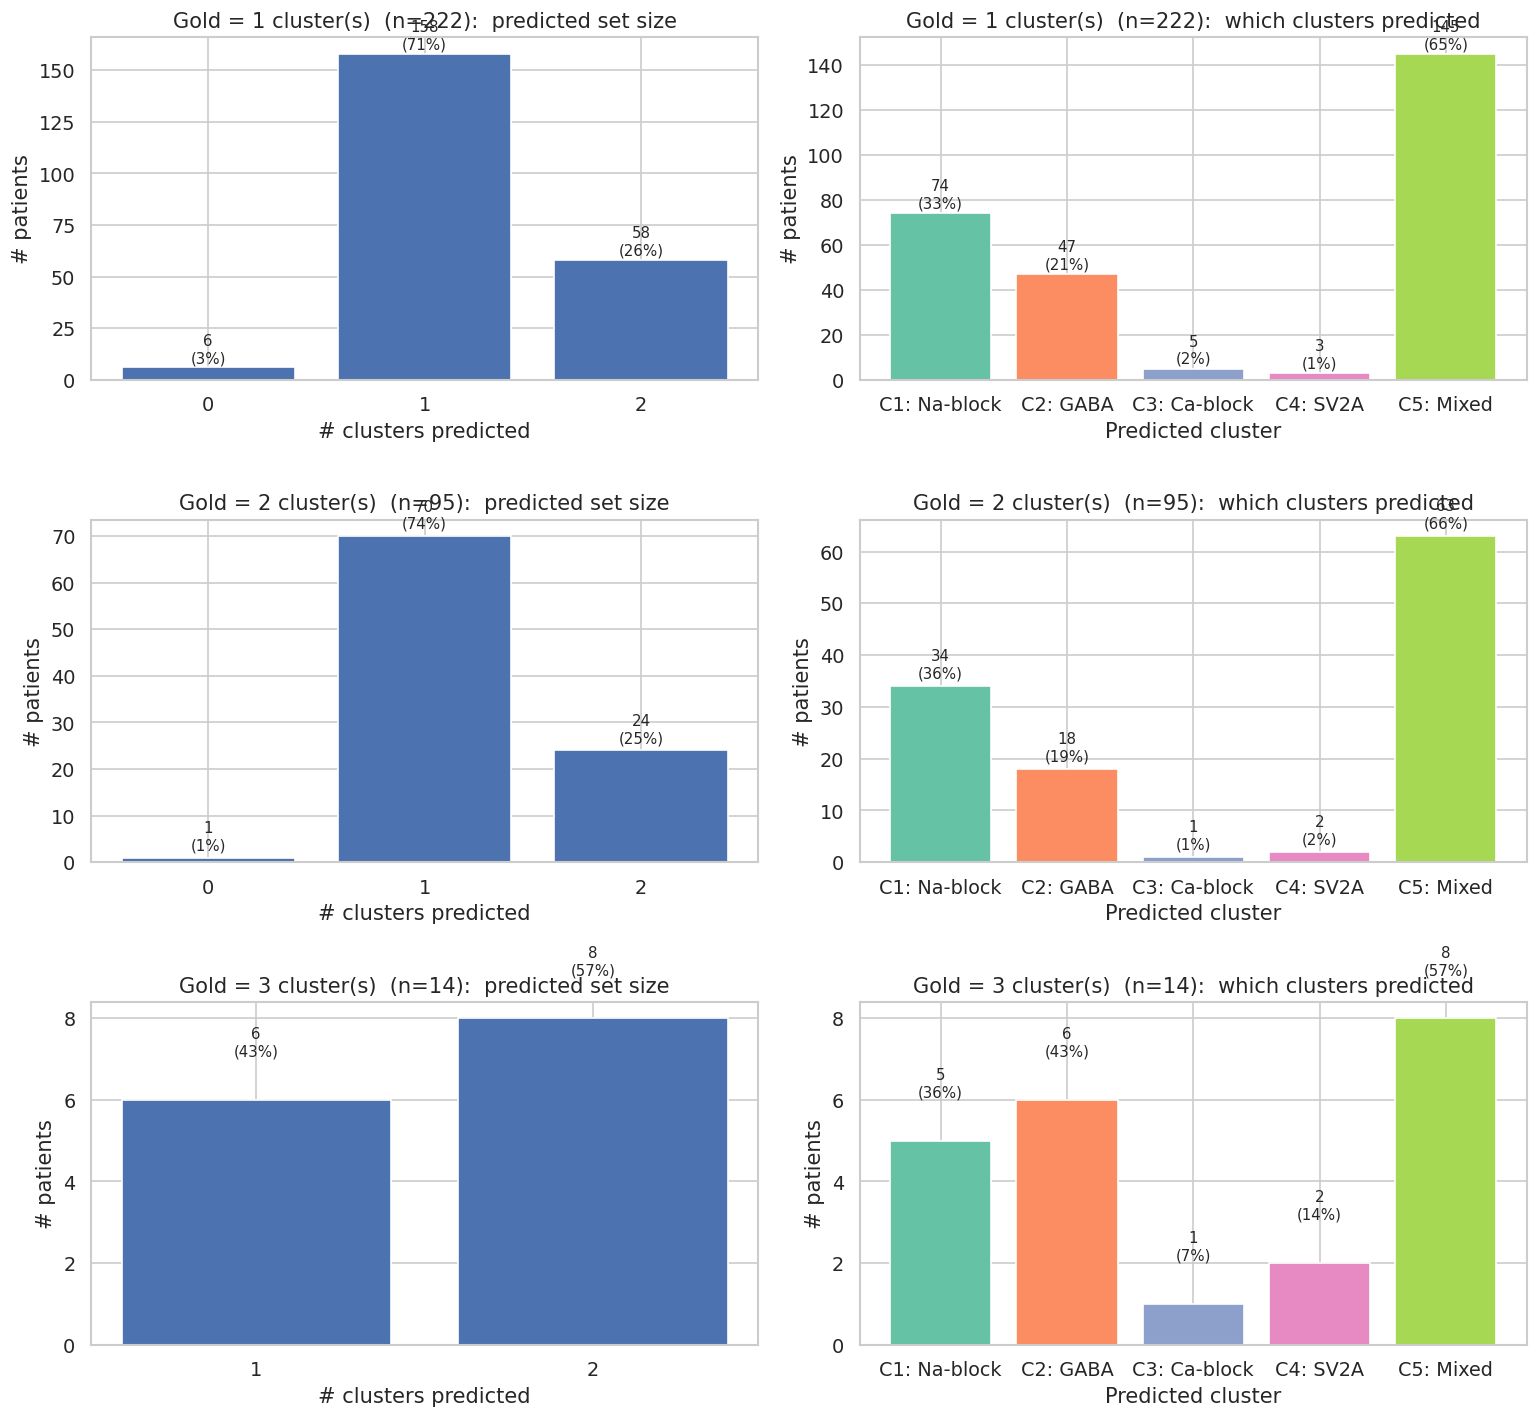

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

gold_sizes = sorted(set(len(gold_clusters[pid]) for pid in valid))
# skip 0-gold group if only 1 patient
gold_sizes = [gs for gs in gold_sizes if sum(1 for pid in valid if len(gold_clusters[pid]) == gs) > 1]

n_groups = len(gold_sizes)
fig, axes = plt.subplots(n_groups, 2, figsize=(13, 4 * n_groups))
if n_groups == 1:
    axes = axes.reshape(1, -1)

cluster_short = {1: 'C1: Na-block', 2: 'C2: GABA', 3: 'C3: Ca-block', 4: 'C4: SV2A', 5: 'C5: Mixed'}
colors_cluster = sns.color_palette('Set2', 5)

for row, n_gold in enumerate(gold_sizes):
    pids = [pid for pid in valid if len(gold_clusters[pid]) == n_gold]
    preds = [pred_clusters[pid] for pid in pids]
    n = len(pids)

    # LEFT: how many clusters does the model predict?
    ax_l = axes[row, 0]
    pred_size_dist = Counter(len(p) for p in preds)
    sizes = sorted(pred_size_dist)
    counts = [pred_size_dist[s] for s in sizes]
    bars = ax_l.bar([str(s) for s in sizes], counts, color='#4C72B0', edgecolor='white')
    for bar, cnt in zip(bars, counts):
        ax_l.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                  f'{cnt}\n({cnt/n*100:.0f}%)', ha='center', va='bottom', fontsize=9)
    ax_l.set_xlabel('# clusters predicted')
    ax_l.set_ylabel('# patients')
    ax_l.set_title(f'Gold = {n_gold} cluster(s)  (n={n}):  predicted set size')

    # RIGHT: which clusters get predicted?
    ax_r = axes[row, 1]
    freqs = []
    for c in range(1, 6):
        freqs.append(sum(1 for p in preds if c in p))
    bars = ax_r.bar([cluster_short[c] for c in range(1, 6)], freqs,
                    color=colors_cluster, edgecolor='white')
    for bar, cnt in zip(bars, freqs):
        ax_r.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                  f'{cnt}\n({cnt/n*100:.0f}%)', ha='center', va='bottom', fontsize=9)
    ax_r.set_xlabel('Predicted cluster')
    ax_r.set_ylabel('# patients')
    ax_r.set_title(f'Gold = {n_gold} cluster(s)  (n={n}):  which clusters predicted')

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# ANALYSIS 1: Top error patterns (gold set → pred set)
# ============================================================
error_patterns = Counter()
for pid in valid:
    g, p = gold_clusters[pid], pred_clusters[pid]
    if g != p:
        error_patterns[(frozenset(g), frozenset(p))] += 1

print('=== TOP 15 ERROR PATTERNS (gold → pred) ===')
for (g, p), cnt in error_patterns.most_common(15):
    gs = '{' + ','.join(f'C{c}' for c in sorted(g)) + '}' if g else '{}'
    ps = '{' + ','.join(f'C{c}' for c in sorted(p)) + '}' if p else '{}'
    fp = sorted(p - g)
    fn = sorted(g - p)
    fp_str = f"  +{fp}" if fp else ''
    fn_str = f"  -{fn}" if fn else ''
    print(f'  {gs:20s} → {ps:20s}  n={cnt}{fp_str}{fn_str}')

=== TOP 15 ERROR PATTERNS (gold → pred) ===
  {C1}                 → {C5}                  n=38  +[5]  -[1]
  {C1,C5}              → {C5}                  n=22  -[1]
  {C5}                 → {C2,C5}               n=21  +[2]
  {C1,C5}              → {C1}                  n=18  -[5]
  {C2,C5}              → {C5}                  n=12  -[2]
  {C1}                 → {C1,C2}               n=12  +[2]
  {C5}                 → {C1}                  n=11  +[1]  -[5]
  {C1}                 → {C2,C5}               n=10  +[2, 5]  -[1]
  {C4,C5}              → {C5}                  n=5  -[4]
  {C1}                 → {C1,C5}               n=4  +[5]
  {C1,C5}              → {C2,C5}               n=4  +[2]  -[1]
  {C1,C4}              → {C1}                  n=3  -[4]
  {C5}                 → {C3}                  n=3  +[3]  -[5]
  {C1}                 → {}                    n=3  -[1]
  {C5}                 → {C1,C2}               n=3  +[1, 2]  -[5]


In [48]:
# ============================================================
# ANALYSIS 2: C2 FP deep dive — when model wrongly adds C2,
#             what else is in the prediction?
# ============================================================
c2_fp_pids = [pid for pid in valid if 2 in pred_clusters[pid] and 2 not in gold_clusters[pid]]
print(f'=== C2 FALSE POSITIVES: {len(c2_fp_pids)} patients ===')

# What else was predicted alongside C2 in FP cases?
co_pred_with_c2_fp = Counter()
for pid in c2_fp_pids:
    for c in pred_clusters[pid]:
        if c != 2:
            co_pred_with_c2_fp[c] += 1

print(f'\nWhat else was predicted alongside C2 (in FP cases):')
for c, cnt in co_pred_with_c2_fp.most_common():
    print(f'  C{c} ({CLUSTER_NAMES[c][:25]}): {cnt} ({cnt/len(c2_fp_pids)*100:.0f}%)')

# What was the gold in these FP cases?
print(f'\nWhat was gold for these patients (C2 FP):')
gold_in_c2_fp = Counter(frozenset(gold_clusters[pid]) for pid in c2_fp_pids)
for gs, cnt in gold_in_c2_fp.most_common(10):
    gs_str = '{' + ','.join(f'C{c}' for c in sorted(gs)) + '}' if gs else '{}'
    print(f'  gold={gs_str}: {cnt}')

# Was C2 a pure hedge (rest of pred was correct)?
pure_hedge = sum(1 for pid in c2_fp_pids
                 if gold_clusters[pid] == (pred_clusters[pid] - {2}))
print(f'\nC2 was pure hedge (pred - C2 == gold): {pure_hedge}/{len(c2_fp_pids)} ({pure_hedge/len(c2_fp_pids)*100:.0f}%)')

=== C2 FALSE POSITIVES: 62 patients ===

What else was predicted alongside C2 (in FP cases):
  C5 (Mixed-mechanism drugs): 40 (65%)
  C1 (Sodium channel blockers): 28 (45%)

What was gold for these patients (C2 FP):
  gold={C5}: 26
  gold={C1}: 22
  gold={C1,C5}: 11
  gold={C1,C4,C5}: 1
  gold={C4}: 1
  gold={C4,C5}: 1

C2 was pure hedge (pred - C2 == gold): 30/62 (48%)


In [49]:
# ============================================================
# ANALYSIS 3: C4 near-total failure — when C4 is in gold
#             and model misses it, what does it predict instead?
# ============================================================
c4_gold_pids = [pid for pid in valid if 4 in gold_clusters[pid]]
c4_fn_pids   = [pid for pid in c4_gold_pids if 4 not in pred_clusters[pid]]
c4_tp_pids   = [pid for pid in c4_gold_pids if 4 in pred_clusters[pid]]

print(f'=== C4 ANALYSIS: {len(c4_gold_pids)} patients with C4 in gold ===')
print(f'  TP (C4 predicted correctly): {len(c4_tp_pids)}')
print(f'  FN (C4 missed):              {len(c4_fn_pids)}')

print(f'\nFor C4 FN cases — what was predicted instead:')
substitutes = Counter()
for pid in c4_fn_pids:
    for c in pred_clusters[pid]:
        substitutes[c] += 1
for c, cnt in substitutes.most_common():
    print(f'  C{c} ({CLUSTER_NAMES[c][:25]}): {cnt} ({cnt/len(c4_fn_pids)*100:.0f}%)')

print(f'\nFor C4 FN cases — full pred sets:')
c4_fn_preds = Counter(frozenset(pred_clusters[pid]) for pid in c4_fn_pids)
for ps, cnt in c4_fn_preds.most_common(8):
    ps_str = '{' + ','.join(f'C{c}' for c in sorted(ps)) + '}' if ps else '{}'
    print(f'  pred={ps_str}: {cnt}')

print(f'\nFor C4 FN cases — what was gold:')
c4_fn_golds = Counter(frozenset(gold_clusters[pid]) for pid in c4_fn_pids)
for gs, cnt in c4_fn_golds.most_common(8):
    gs_str = '{' + ','.join(f'C{c}' for c in sorted(gs)) + '}' if gs else '{}'
    print(f'  gold={gs_str}: {cnt}')

=== C4 ANALYSIS: 21 patients with C4 in gold ===
  TP (C4 predicted correctly): 1
  FN (C4 missed):              20

For C4 FN cases — what was predicted instead:
  C5 (Mixed-mechanism drugs): 14 (70%)
  C1 (Sodium channel blockers): 9 (45%)
  C2 (GABA-enhancing drugs): 4 (20%)

For C4 FN cases — full pred sets:
  pred={C5}: 8
  pred={C1}: 4
  pred={C1,C5}: 3
  pred={C2,C5}: 2
  pred={}: 1
  pred={C1,C2,C5}: 1
  pred={C1,C2}: 1

For C4 FN cases — what was gold:
  gold={C4,C5}: 7
  gold={C1,C4}: 6
  gold={C4}: 4
  gold={C2,C4,C5}: 2
  gold={C1,C4,C5}: 1


In [50]:
# ============================================================
# ANALYSIS 4: C2 conditional — given model predicts C2,
#             how often is it actually in gold? (precision breakdown)
# ============================================================
c2_pred_pids = [pid for pid in valid if 2 in pred_clusters[pid]]
c2_prec = sum(1 for pid in c2_pred_pids if 2 in gold_clusters[pid])
print(f'=== C2 PRECISION BREAKDOWN ===')
print(f'Model predicted C2: {len(c2_pred_pids)} patients')
print(f'C2 actually in gold: {c2_prec} ({c2_prec/len(c2_pred_pids)*100:.0f}%)')
print(f'C2 was a FP: {len(c2_pred_pids)-c2_prec} ({(len(c2_pred_pids)-c2_prec)/len(c2_pred_pids)*100:.0f}%)')

# Among C2 TP cases — what features triggered correct C2?
print(f'\nC2 TP cases — full gold sets:')
c2_tp_pids = [pid for pid in c2_pred_pids if 2 in gold_clusters[pid]]
for gs, cnt in Counter(frozenset(gold_clusters[pid]) for pid in c2_tp_pids).most_common():
    gs_str = '{' + ','.join(f'C{c}' for c in sorted(gs)) + '}'
    print(f'  gold={gs_str}: {cnt}')

# Among C2 FP cases — what was the gold (what was the model confused about)?
print(f'\nC2 FP cases — full gold sets (what the model should have predicted):')
c2_fp_pids2 = [pid for pid in c2_pred_pids if 2 not in gold_clusters[pid]]
for gs, cnt in Counter(frozenset(gold_clusters[pid]) for pid in c2_fp_pids2).most_common(10):
    gs_str = '{' + ','.join(f'C{c}' for c in sorted(gs)) + '}'
    print(f'  gold={gs_str}: {cnt}')

=== C2 PRECISION BREAKDOWN ===
Model predicted C2: 74 patients
C2 actually in gold: 12 (16%)
C2 was a FP: 62 (84%)

C2 TP cases — full gold sets:
  gold={C2,C5}: 6
  gold={C1,C2,C5}: 5
  gold={C2,C4,C5}: 1

C2 FP cases — full gold sets (what the model should have predicted):
  gold={C5}: 26
  gold={C1}: 22
  gold={C1,C5}: 11
  gold={C1,C4,C5}: 1
  gold={C4}: 1
  gold={C4,C5}: 1


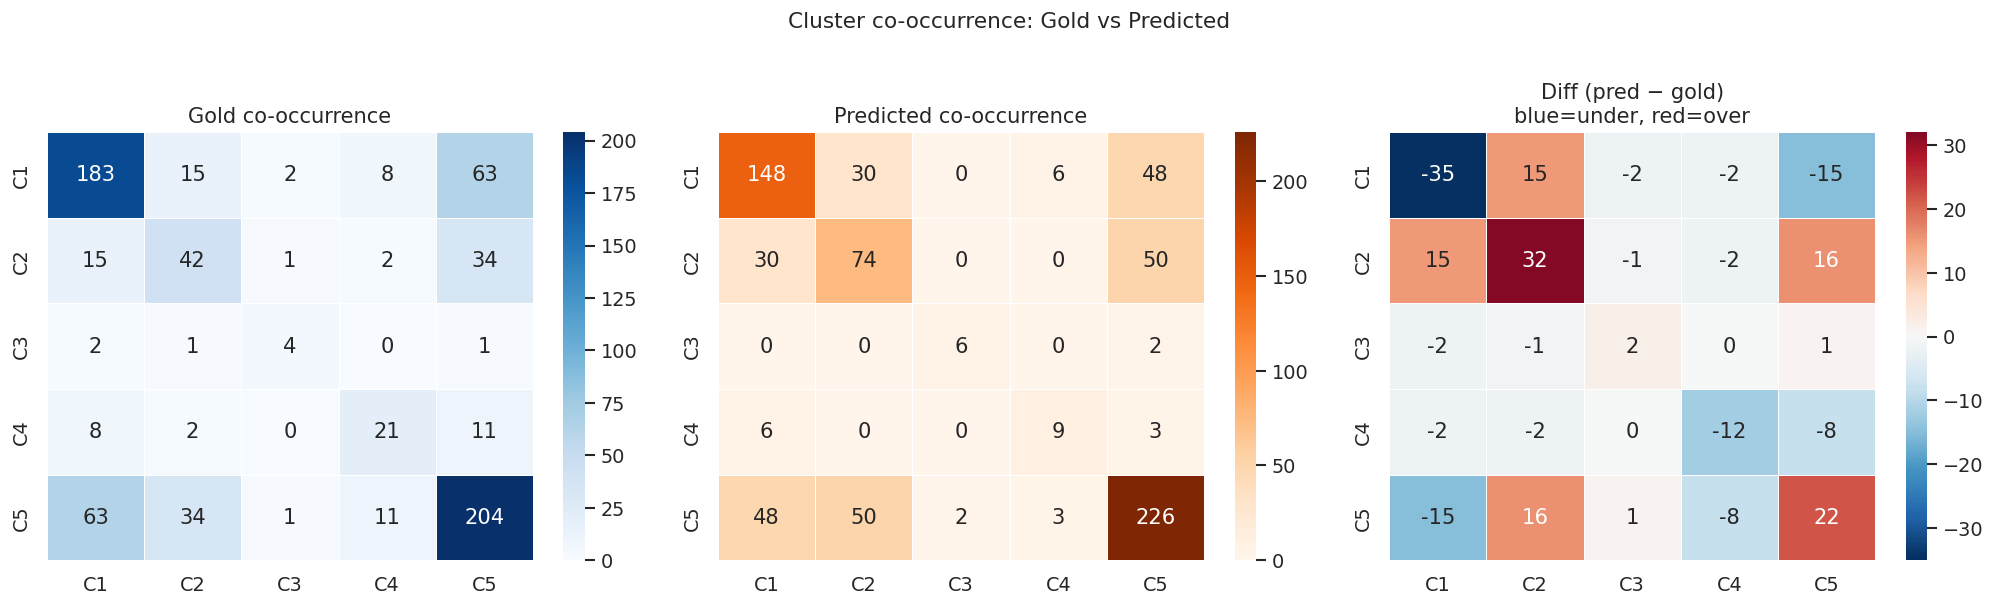

In [51]:
# ============================================================
# ANALYSIS 5: Co-prediction vs co-gold heatmaps
#             Which clusters co-occur in gold vs in predictions?
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

def cooccurrence_matrix(cluster_sets, n=5):
    mat = np.zeros((n, n), dtype=int)
    for s in cluster_sets:
        for i in s:
            for j in s:
                mat[i-1][j-1] += 1
    return mat

gold_sets = [gold_clusters[pid] for pid in valid]
pred_sets = [pred_clusters[pid] for pid in valid]

co_gold = cooccurrence_matrix(gold_sets)
co_pred = cooccurrence_matrix(pred_sets)
diff = co_pred - co_gold  # positive = over-predicted together, negative = under-predicted

labels = [f'C{c}' for c in range(1, 6)]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.heatmap(co_gold, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels, linewidths=0.5)
axes[0].set_title('Gold co-occurrence')

sns.heatmap(co_pred, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=labels, yticklabels=labels, linewidths=0.5)
axes[1].set_title('Predicted co-occurrence')

sns.heatmap(diff, annot=True, fmt='d', cmap='RdBu_r', center=0, ax=axes[2],
            xticklabels=labels, yticklabels=labels, linewidths=0.5)
axes[2].set_title('Diff (pred − gold)\nblue=under, red=over')

plt.suptitle('Cluster co-occurrence: Gold vs Predicted', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()